# A/B Test Significance Analysis
### Does Advertising Cause Real Conversions — Or Is It Random Chance?

This notebook tests whether an advertising campaign caused a statistically
significant lift in conversions compared to a PSA (public service
announcement) control group, using live data queried directly from BigQuery.

**Dataset:** 588,101 users split into an ad-exposed group and a PSA control group.

---
## Step 1: Import Libraries

In [13]:
!pip install google-cloud-bigquery --quite



Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quite


In [14]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import zt_ind_solve_power
print("all libraries loaded succefully")

all libraries loaded succefully


## Step 2: Authenticate with Google Cloud
Connecting this notebook to the same Google account used for BigQuery,
so we can query live data rather than working from static exports.
## Step 3: Connect to BigQuery and Pull Conversion Data
Querying the same `marketing_ab_test` table directly from BigQuery —
this ensures the analysis always reflects the current state of the data.

In [15]:
from google.colab import auth
from google.cloud import bigquery

# 1. Force the login process again
print("Waiting for Google authentication...")
auth.authenticate_user()
print("Authentication secure!")

# 2. Connect to your specific project
project_id = 'paid-compaigns-porject'
client = bigquery.Client(project=project_id)

# 3. Run the query
query = """
SELECT
  test_group,
  COUNT(*) AS total_users,
  COUNTIF(converted = TRUE) AS conversions,
  ROUND(COUNTIF(converted = TRUE) * 100.0 / COUNT(*), 4) AS conversion_rate_pct
FROM `paid-compaigns-porject.ab_testing_analysis.marketing_ab_test`
GROUP BY test_group
"""

# 4. Pull and print the results
results_df = client.query(query).to_dataframe()
print(results_df)

Waiting for Google authentication...
Authentication secure!
  test_group  total_users  conversions  conversion_rate_pct
0         ad       564577        14423               2.5547
1        psa        23524          420               1.7854


## Step 4: Extract Group Values
Pulling the ad group and PSA group numbers out of the query result
into individual variables for the statistical tests below.

In [16]:
ad_row = results_df[results_df['test_group'] == 'ad'].iloc[0]
psa_row = results_df[results_df['test_group'] == 'psa'].iloc[0]

ad_users = ad_row['total_users']
ad_conversions = ad_row['conversions']
psa_users = psa_row['total_users']
psa_conversions = psa_row['conversions']

print(f"Ad_group: {ad_users} users, {ad_conversions} conversions")
print(f"PSA_group: {psa_users} users, {psa_conversions} conversions")


Ad_group: 564577 users, 14423 conversions
PSA_group: 23524 users, 420 conversions


## Step 5: Sample Ratio Mismatch (SRM) Check
Before trusting any A/B test result, we confirm the traffic split between
groups wasn't corrupted by a tracking bug. A Chi-square goodness-of-fit
test checks whether the observed 96%/4% split matches the expected design.

**Result: Passed** — no mismatch detected (p = 0.9998).

In [17]:
# Sample Ratio Mismatch check using Chi-square test
total_users = ad_users + psa_users
# We observed a 96/4 split - check if this matches expectations
observed = [ad_users, psa_users]
expected_ratio = [0.96, 0.04] # based on what we found is the intentional design
expected = [total_users * r for r in expected_ratio]

chi_stat, srm_p_value = chisquare(observed, expected)

print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"p-value: {srm_p_value:.6f}")
if srm_p_value < 0.01:
    print(" WARNING: Sample Ratio Mismatch detected")
else:
    print(" No SRM detected — split matches expected design")

Chi-square statistic: 0.0000
p-value: 0.999788
 No SRM detected — split matches expected design


## Step 6: Two-Proportion Z-Test — The Core Significance Test
This test answers the central question: is the ad group's higher conversion
rate a real effect, or could it be explained by random chance alone?

**Result: Statistically significant** (Z = 7.37, p < 0.0000000001) —
a 43.09% relative lift over the PSA control group.

In [18]:
# Two-Proportion Z-Test for statistical significance
counts = np.array([ad_conversions, psa_conversions])
nobs = np.array([ad_users, psa_users])

z_stat, p_value = proportions_ztest(counts, nobs)
ad_rate = ad_conversions / ad_users
psa_rate = psa_conversions / psa_users
relative_lift = (ad_rate - psa_rate) / psa_rate * 100

print(f"ad group conversion rate : {ad_rate * 100:.4f}%")
print(f"psa group conversion rate : {psa_rate * 100:.4f}%")
print(f"Relative lift: {relative_lift:.2f}%")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.05:
    print("\n statistically significant - very unlikley this is due to random chance")
else:
    print("\n Not statistically significant")

ad group conversion rate : 2.5547%
psa group conversion rate : 1.7854%
Relative lift: 43.09%

Z-statistic: 7.3701
p-value: 0.0000000000

 statistically significant - very unlikley this is due to random chance


## Step 7: Confidence Interval & Incremental Conversions
The confidence interval shows the range we're 95% confident contains the
true conversion rate. Incremental conversions translate the statistical
result into a real business number — how many extra sales the ads caused.

**Result:** 95% CI [2.51%, 2.60%] | 4,343 incremental conversions.

In [19]:
# Confidence Interval - the range we're 95% confident the true rate falls within
chi_low, chi_high = proportion_confint(ad_conversions, ad_users, alpha=0.05)

print(f"95% donfident interval for ad group conversion rate:")
print(f"[{chi_low * 100:.4f}%, {chi_high * 100:.4f}%]")

incremental_converions = ad_conversions -(ad_users * psa_rate)

print(f"\nIncremental conversion driven by ads : {incremental_converions:.4f}")
print(f"(This means: without the ads, we would expect only{ad_users*psa_rate:.0f} conversion from this many users)")

95% donfident interval for ad group conversion rate:
[2.5135%, 2.5958%]

Incremental conversion driven by ads : 4342.9821
(This means: without the ads, we would expect only10080 conversion from this many users)


## Step 8: Power Analysis
Statistical significance alone isn't enough — we also need to confirm
the sample size was large enough to detect this effect reliably, not
just by luck. Using Cohen's h (the correct standardized effect size for
proportions) to calculate the minimum sample size needed.

**Result:** Test was adequately powered — actual sample was 4.2x the
minimum required.

In [20]:
# Power Analysis - using Cohen's h (the statistically correct method for proportions)
h_effect_size = proportion_effectsize(ad_rate, psa_rate)

required_n = zt_ind_solve_power(
    effect_size = h_effect_size,
    alpha = 0.05,
    power = 0.8,
    ratio = 1
)
print(f"Cohen's h effect size: {h_effect_size:.4f}")
print(f"Minimum sample size needed per group (for 80% power): {required_n:.0f}")
print(f"Actual PSA group size: {psa_users}")

if psa_users >= required_n:
    print(f"\n Test was adequately powered — actual sample was {psa_users/required_n:.1f}x the minimum needed")
else:
    print(f"\n Test may be underpowered")


Cohen's h effect size: 0.0530
Minimum sample size needed per group (for 80% power): 5588
Actual PSA group size: 23524

 Test was adequately powered — actual sample was 4.2x the minimum needed


## Step 9: Visualizing the Core Finding

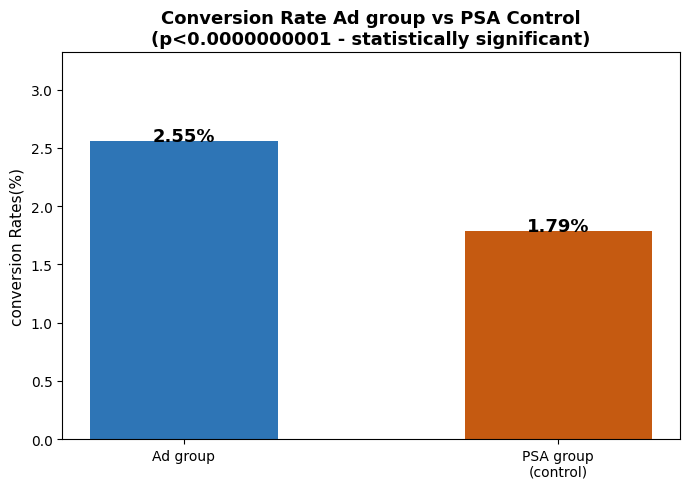

In [21]:
import matplotlib.pyplot as plt

groups = ['Ad group', 'PSA group\n(control)']
rates = [ad_rate * 100, psa_rate * 100]
colors = ['#2E75B6', '#C55A11']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(groups, rates, color=colors, width=0.5)


for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{rate:.2f}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('conversion Rates(%)', fontsize=11)
ax.set_title('Conversion Rate Ad group vs PSA Control\n(p<0.0000000001 - statistically significant)',
             fontsize=13, fontweight='bold')

ax.set_ylim(0, max(rates) * 1.3)
plt.tight_layout()
plt.savefig('conversion_rate_compatison.png', dpi=150)

plt.show()


## Step 10: Ad Frequency Analysis — Testing for Selection Bias
Does showing someone more ads always increase conversion? To check this
properly, we compare the ad group against the PSA control group at
matching frequency levels — if both groups rise similarly, that signals
a confound (highly engaged users naturally see more impressions and
convert more, regardless of the ad itself).

**Finding:** Both groups rise with frequency, confirming an engagement-level
confound — but the ad group still outperforms PSA by 5-6 percentage points
at matching frequency levels, indicating a genuine incremental ad effect.

In [22]:
query_freq = """
SELECT
  test_group,
  CASE
    WHEN total_ads BETWEEN 1 AND 25 THEN '1-25'
    WHEN total_ads BETWEEN 26 AND 50 THEN '26-50'
    WHEN total_ads BETWEEN 51 AND 100 THEN '51-100'
    WHEN total_ads BETWEEN 101 AND 250 THEN '101-250'
    WHEN total_ads > 250 THEN '250+'
  END AS ad_frequency_bucket,
  COUNT(*) AS users,
  COUNTIF(converted = TRUE) AS conversions,
  ROUND(COUNTIF(converted = TRUE) * 100.0 / COUNT(*), 4) AS conversion_rate_pct
FROM `paid-compaigns-porject.ab_testing_analysis.marketing_ab_test`
GROUP BY test_group, ad_frequency_bucket
"""

freq_df = client.query(query_freq).to_dataframe()
print(freq_df)

  test_group ad_frequency_bucket   users  conversions  conversion_rate_pct
0         ad                1-25  412634         2472               0.5991
1        psa                1-25   17388          106               0.6096
2         ad               26-50   85740         3037               3.5421
3        psa               26-50    3273           87               2.6581
4         ad              51-100   44149         5135              11.6311
5        psa              51-100    1853          107               5.7744
6         ad             101-250   18584         3225              17.3536
7        psa             101-250     864           97              11.2269
8         ad                250+    3470          554              15.9654
9        psa                250+     146           23              15.7534


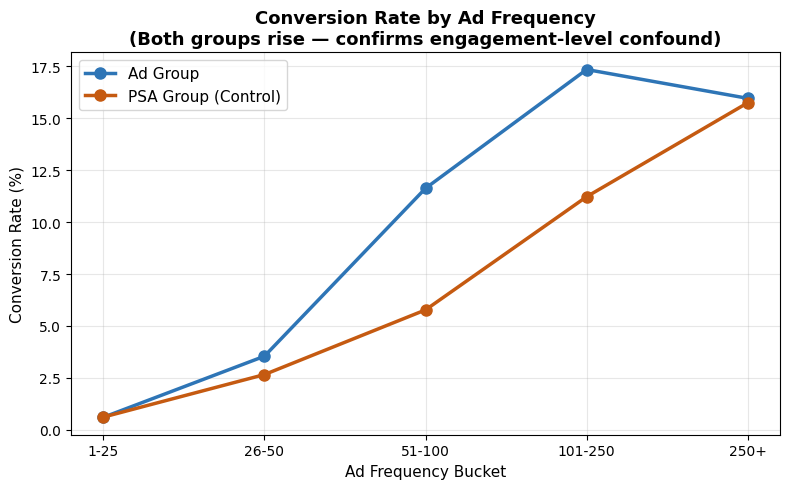

In [23]:
# Reorder buckets correctly (BigQuery may return them unordered)
bucket_order = ['1-25', '26-50', '51-100', '101-250', '250+']
freq_df['ad_frequency_bucket'] = pd.Categorical(freq_df['ad_frequency_bucket'], categories=bucket_order, ordered=True)
freq_df = freq_df.sort_values('ad_frequency_bucket')

# Split into two separate lines
ad_data = freq_df[freq_df['test_group'] == 'ad'].sort_values('ad_frequency_bucket')
psa_data = freq_df[freq_df['test_group'] == 'psa'].sort_values('ad_frequency_bucket')

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ad_data['ad_frequency_bucket'], ad_data['conversion_rate_pct'],
        marker='o', linewidth=2.5, markersize=8, color='#2E75B6', label='Ad Group')
ax.plot(psa_data['ad_frequency_bucket'], psa_data['conversion_rate_pct'],
        marker='o', linewidth=2.5, markersize=8, color='#C55A11', label='PSA Group (Control)')

ax.set_xlabel('Ad Frequency Bucket', fontsize=11)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_title('Conversion Rate by Ad Frequency\n(Both groups rise — confirms engagement-level confound)',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ad_frequency_dose_response.png', dpi=150)
plt.show()

## Conclusion
The advertising campaign drove a statistically significant, substantial
lift in conversions (43.09% relative lift, p < 0.0000000001), generating
an estimated 4,343 incremental sales. The test was adequately powered,
and the Sample Ratio Mismatch check confirmed the experiment's integrity.

**Recommendation:** Continue and scale the campaign. Cap ad frequency
around 250 impressions per user, where returns plateau in both groups.
Note that the ad-frequency relationship is partially confounded by user
engagement level — this should inform, not solely determine, budget decisions.